# Notebook #7: Evaluating Machine Teaching for XAI with Multimodal LLMs
#### by Sebastian Einar Salas Rokholt

---

**Summary**  
This notebook runs the multimodal LLM (MLLM) experiment and analyses participant-level results.

---

**Index**
1. Setup and imports
2. Run the MLLM experiment (30 participants across groups A-F)
3. Load and quality-check `participants.csv`
4. Estimate relative teaching effect versus baseline group F
5. Visualise and rank group effects


### 0 - Notebook setup and imports

In [1]:
# Standard library and PyPI imports
import os
import sys
import shlex
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Path configuration
PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

RUN_EXPERIMENT = False  # Set to False to skip experiment execution and only run analysis/plotting
PARTICIPANTS_TO_RUN = 120
CONDITIONS = "all"
PARALLEL_PARTICIPANTS = 2
MODEL_NAME = "gpt-5-nano"
EXPERIMENT_RANDOM_SEED = 42

TEACHING_SET_DIR = PROJECT_ROOT / "Figures" / "teaching_sets" / "mllm_experiment_sets"
EXAM_SETS_DIR = PROJECT_ROOT / "Figures" / "exam_sets" / "mllm_experiment_sets"
METADATA_DIR = PROJECT_ROOT / "Data" / "mllm_experiment_metadata"
OUTPUT_DIR = PROJECT_ROOT / "Data" / "mllm_experiment_results" / "gpt-5-nano_experiment_1"
RESULTS_CSV = OUTPUT_DIR / "participants.csv"


# Display and plotting configuration
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
sns.set_theme(style="whitegrid")

# Basic path validation
for required_path in [TEACHING_SET_DIR, EXAM_SETS_DIR, METADATA_DIR, OUTPUT_DIR]:
    if not required_path.exists():
        os.makedirs(required_path)

if not os.getenv("OPENAI_API_KEY"):
    print("Warning: OPENAI_API_KEY is not set. The experiment cell requires a valid key.")

print(f"Project root: {PROJECT_ROOT}")
print(f"Results file: {RESULTS_CSV}")


Project root: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models
Results file: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/mllm_experiment_results/gpt-5-nano_experiment_1/participants.csv


### 1 - Run automated MT4XAI experiment on MLLM participants

In [2]:
# Runs the full trial runner with n participants across all groups (A-F)
run_cmd = [
    sys.executable, "-m", "mllm_experiment.run_trial",
    "--participants", str(PARTICIPANTS_TO_RUN),
    "--conditions", CONDITIONS,
    "--teaching_set_dir", str(TEACHING_SET_DIR),
    "--exam_sets_dir", str(EXAM_SETS_DIR),
    "--metadata_dir", str(METADATA_DIR),
    "--output_dir", str(OUTPUT_DIR),
    "--parallel_participants", str(PARALLEL_PARTICIPANTS),
    "--post_exam_batch_size", "5",
    "--post_exam_missing_repair_attempts", "2",
    "--max_requests_per_minute", "500",
    "--max_tokens_per_minute", "200_000",
    "--group_e_teaching_context_window_examples", "5",
    "--group_e_post_exam_rule_max_chars", "1000", 
    "--log_level", "CRITICAL",
    "--random_seed", str(EXPERIMENT_RANDOM_SEED),
    "--model_name", MODEL_NAME,
]


if RUN_EXPERIMENT:
    
    print("Running command:")
    print(" ".join(shlex.quote(part) for part in run_cmd))


    completed_process = subprocess.run(
        run_cmd,
        cwd=PROJECT_ROOT,
        check=True,
    )

    print(f"Trial runner finished with return code {completed_process.returncode}.")
    print(f"Participant summary file: {RESULTS_CSV}")
else: 
    print("RUN_EXPERIMENT is set to False. Skipping experiment execution and only running analysis/plotting.")

RUN_EXPERIMENT is set to False. Skipping experiment execution and only running analysis/plotting.


### 2 - Load and validate participant results

In [3]:
participants_df = pd.read_csv(RESULTS_CSV)
participants_df["group"] = participants_df["group"].astype(str).str.strip().str.upper()
participants_df["status"] = participants_df["status"].astype(str).str.strip().str.lower()

for metric_col in ["accuracy_pre", "accuracy_post", "delta_accuracy"]:
    participants_df[metric_col] = pd.to_numeric(participants_df[metric_col], errors="coerce")

group_order = list("ABCDEF")

status_counts = (
    participants_df
    .pivot_table(index="group", columns="status", values="participant_id", aggfunc="count", fill_value=0)
    .reindex(group_order)
    .fillna(0)
    .astype(int)
)

print("Participant counts by group and status")
display(status_counts)

completed_df = participants_df.loc[
    (participants_df["status"] == "completed")
    & (participants_df["group"].isin(group_order))
].copy()
completed_df = completed_df.dropna(subset=["delta_accuracy"])

if completed_df.empty:
    raise ValueError("No completed participants with valid delta_accuracy were found.")

print(f"Completed participants used for effect analysis: {len(completed_df)}")
display(completed_df.head())


Participant counts by group and status


status,completed
group,
A,18
B,16
C,16
D,15
E,18
F,18


Completed participants used for effect analysis: 101


,participant_id,group,exam_set_pre,exam_set_post,accuracy_pre,accuracy_post,delta_accuracy,status,error_type,error_message
0,p_0000_7cfb5154,B,set2,set1,0.5000,0.6333,0.1333,completed,NaN,NaN
1,p_0001_57250a21,A,set2,set1,0.5000,0.7667,0.2667,completed,NaN,NaN
2,p_0003_627d7f9a,E,set2,set1,0.5000,0.6333,0.1333,completed,NaN,NaN
3,p_0004_593c5b52,F,set1,set2,0.5333,0.5333,0.0000,completed,NaN,NaN
4,p_0002_857dfda9,C,set2,set1,0.5667,0.6000,0.0333,completed,NaN,NaN


### 3 - Relative teaching effect of groups A-E versus baseline group F

In [4]:
def bootstrap_mean_difference_ci(
    sample_group: np.ndarray,
    sample_baseline: np.ndarray,
    rng: np.random.Generator,
    n_bootstrap: int = 20_000,
    alpha: float = 0.05,
) -> tuple[float, float]:
    """Estimate a percentile bootstrap confidence interval for a mean difference.

    Args:
        sample_group: Sample values for one teaching group.
        sample_baseline: Sample values for baseline group F.
        rng: Random number generator.
        n_bootstrap: Number of bootstrap replications.
        alpha: Significance level used for the two-sided interval.

    Returns:
        Tuple with lower and upper confidence bounds.
    """
    sample_group = np.asarray(sample_group, dtype=float)
    sample_baseline = np.asarray(sample_baseline, dtype=float)

    group_idx = rng.integers(0, sample_group.size, size=(n_bootstrap, sample_group.size))
    base_idx = rng.integers(0, sample_baseline.size, size=(n_bootstrap, sample_baseline.size))
    sampled_diffs = sample_group[group_idx].mean(axis=1) - sample_baseline[base_idx].mean(axis=1)

    lower_q = alpha / 2
    upper_q = 1 - (alpha / 2)
    return float(np.quantile(sampled_diffs, lower_q)), float(np.quantile(sampled_diffs, upper_q))


group_stats = (
    completed_df.groupby("group", as_index=False)["delta_accuracy"]
    .agg(n="size", mean_delta="mean", std_delta="std")
    .set_index("group")
    .reindex(group_order)
)
print("Mean post-pre accuracy shift by group")
display(group_stats)

baseline_delta = completed_df.loc[completed_df["group"] == "F", "delta_accuracy"].to_numpy()
if baseline_delta.size == 0:
    raise ValueError("Baseline group F has no completed participants.")

baseline_mean = float(baseline_delta.mean())
effect_rows = []
rng = np.random.default_rng(42)

for group in list("ABCDE"):
    group_delta = completed_df.loc[completed_df["group"] == group, "delta_accuracy"].to_numpy()
    if group_delta.size == 0:
        continue

    relative_effect = float(group_delta.mean() - baseline_mean)
    ci_low, ci_high = bootstrap_mean_difference_ci(
        sample_group=group_delta,
        sample_baseline=baseline_delta,
        rng=rng,
    )

    _, p_value = stats.ttest_ind(group_delta, baseline_delta, equal_var=False)

    pooled_sd = np.sqrt((group_delta.var(ddof=1) + baseline_delta.var(ddof=1)) / 2)
    cohen_d = float(relative_effect / pooled_sd) if pooled_sd > 0 else np.nan

    effect_rows.append(
        {
            "group": group,
            "n_group": int(group_delta.size),
            "mean_delta_accuracy": float(group_delta.mean()),
            "baseline_mean_delta_F": baseline_mean,
            "relative_teaching_effect": relative_effect,
            "relative_teaching_effect_pp": relative_effect * 100,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "welch_p_value": float(p_value),
            "cohen_d_vs_F": cohen_d,
        }
    )

effect_df = pd.DataFrame(effect_rows).sort_values(
    by="relative_teaching_effect",
    ascending=False,
    ignore_index=True,
)

print("Relative teaching effect definition")
print("relative_teaching_effect = mean(delta_accuracy_group) - mean(delta_accuracy_group_F)")
print("Positive values indicate better post-pre accuracy change than baseline F.")

display(effect_df)


Mean post-pre accuracy shift by group


,n,mean_delta,std_delta
group,,,
A,18,0.1204,0.1478
B,16,0.1000,0.1095
C,16,0.0271,0.1323
D,15,0.0756,0.0938
E,18,0.1037,0.0989
F,18,0.0124,0.0656


Relative teaching effect definition
relative_teaching_effect = mean(delta_accuracy_group) - mean(delta_accuracy_group_F)
Positive values indicate better post-pre accuracy change than baseline F.


,group,n_group,mean_delta_accuracy,baseline_mean_delta_F,relative_teaching_effect,relative_teaching_effect_pp,ci95_low,ci95_high,welch_p_value,cohen_d_vs_F
0,A,18,0.1204,0.0124,0.1080,10.7963,0.0352,0.1815,0.0093,0.9442
1,E,18,0.1037,0.0124,0.0913,9.1296,0.0389,0.1456,0.0028,1.0877
2,B,16,0.1000,0.0124,0.0876,8.7593,0.0290,0.1478,0.0103,0.9702
3,D,15,0.0756,0.0124,0.0631,6.3148,0.0065,0.1167,0.0377,0.7801
4,C,16,0.0271,0.0124,0.0147,1.4676,-0.0569,0.0813,0.6918,0.1405


### 4 - Visualisation and ranking

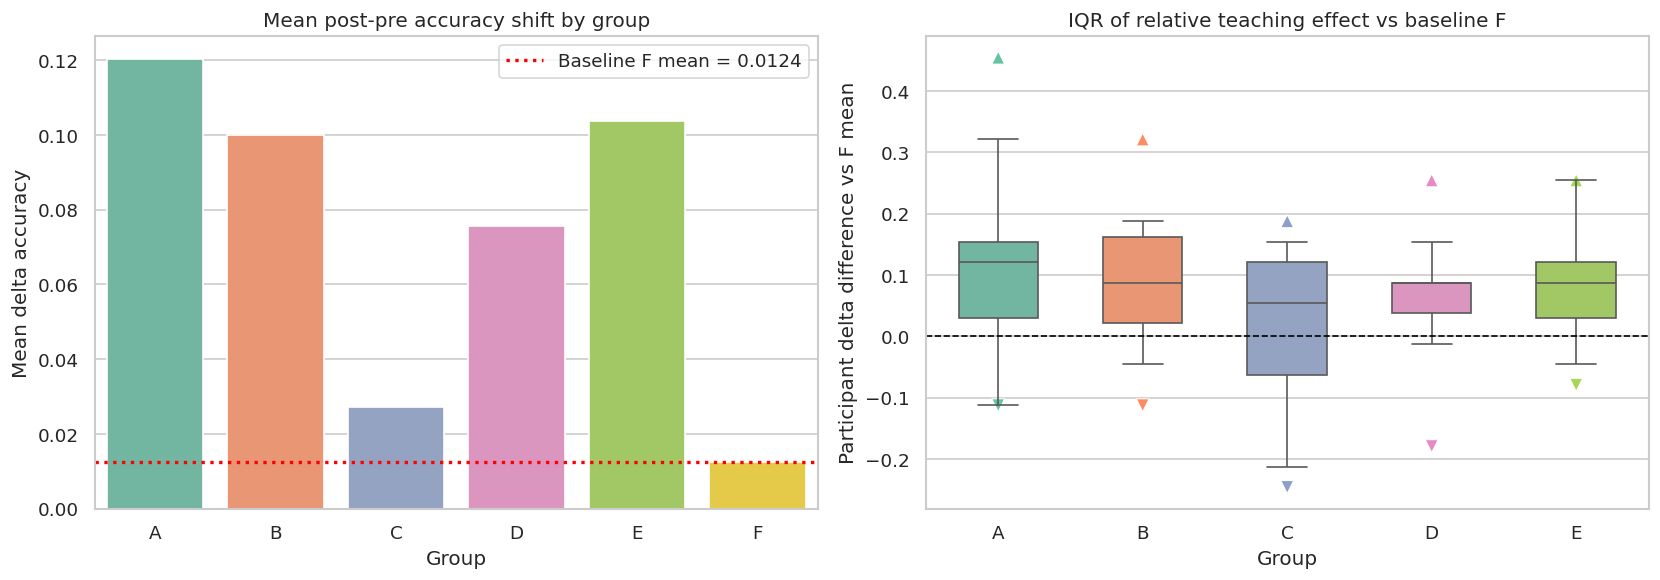

Group ranking by relative teaching effect (best to worst)


,group,relative_teaching_effect,relative_teaching_effect_pp,welch_p_value,cohen_d_vs_F
0,A,0.1080,10.7963,0.0093,0.9442
1,E,0.0913,9.1296,0.0028,1.0877
2,B,0.0876,8.7593,0.0103,0.9702
3,D,0.0631,6.3148,0.0377,0.7801
4,C,0.0147,1.4676,0.6918,0.1405


In [5]:
plot_stats_df = group_stats.reset_index().sort_values("group").copy()
plot_effect_df = effect_df.sort_values("group").copy()
group_order_effect = plot_effect_df["group"].tolist()

iqr_plot_df = completed_df.loc[
    completed_df["group"].isin(group_order_effect),
    ["group", "delta_accuracy"],
].copy()
iqr_plot_df["delta_vs_baseline_F"] = iqr_plot_df["delta_accuracy"] - baseline_mean
iqr_plot_df["group"] = pd.Categorical(iqr_plot_df["group"], categories=group_order_effect, ordered=True)

min_max_df = (
    iqr_plot_df.groupby("group", as_index=False, observed=True)["delta_vs_baseline_F"]
    .agg(min_outlier="min", max_outlier="max")
)
min_max_df["group"] = pd.Categorical(min_max_df["group"], categories=group_order_effect, ordered=True)
outlier_plot_df = min_max_df.melt(
    id_vars="group",
    value_vars=["min_outlier", "max_outlier"],
    var_name="outlier_type",
    value_name="delta_vs_baseline_F",
)
group_palette = dict(
    zip(plot_stats_df["group"], sns.color_palette("Set2", n_colors=plot_stats_df["group"].nunique()))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

sns.barplot(
    data=plot_stats_df,
    x="group",
    y="mean_delta",
    hue="group",
    palette=group_palette,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].axhline(
    baseline_mean,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Baseline F mean = {baseline_mean:.4f}",
)
axes[0].set_title("Mean post-pre accuracy shift by group")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Mean delta accuracy")
axes[0].legend()

sns.boxplot(
    data=iqr_plot_df,
    x="group",
    y="delta_vs_baseline_F",
    hue="group",
    palette=group_palette,
    order=group_order_effect,
    dodge=False,
    legend=False,
    whis=(5, 95),
    showfliers=False,
    width=0.55,
    ax=axes[1],
)
sns.scatterplot(
    data=outlier_plot_df,
    x="group",
    y="delta_vs_baseline_F",
    hue="group",
    style="outlier_type",
    markers={"min_outlier": "v", "max_outlier": "^"},
    palette=group_palette,
    s=60,
    ax=axes[1],
    legend=False,
)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("IQR of relative teaching effect vs baseline F")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Participant delta difference vs F mean")

plt.tight_layout()
plt.show()

ranking_df = effect_df[["group", "relative_teaching_effect", "relative_teaching_effect_pp", "welch_p_value", "cohen_d_vs_F"]].copy()
print("Group ranking by relative teaching effect (best to worst)")
display(ranking_df)


### 5 - Significance of Results

In [6]:
from statsmodels.stats.multitest import multipletests

pvals = effect_df["welch_p_value"].to_numpy()

reject_bonf, p_bonf, _, _ = multipletests(pvals, alpha=0.05, method="bonferroni")
reject_holm, p_holm, _, _ = multipletests(pvals, alpha=0.05, method="holm")

effect_df = effect_df.assign(
    p_bonferroni=p_bonf,
    reject_bonferroni=reject_bonf,
    p_holm=p_holm,
    reject_holm=reject_holm,
)

display(effect_df[["group", "welch_p_value", "p_bonferroni", "reject_bonferroni", 
                   "p_holm", "reject_holm"]]
)

,group,welch_p_value,p_bonferroni,reject_bonferroni,p_holm,reject_holm
0,A,0.0093,0.0466,True,0.0373,True
1,E,0.0028,0.0139,True,0.0139,True
2,B,0.0103,0.0514,False,0.0373,True
3,D,0.0377,0.1886,False,0.0754,False
4,C,0.6918,1.0000,False,0.6918,False


### Summary
The experiment compared post-pre accuracy shifts across participant groups (A-F), with group F serving as the baseline.
Groups A, E, and B exhibit the highest relative teaching effects, with statistically significant improvements over baseline F. 
Bonferroni and Holm corrections confirm significance for groups A and E, while group B is significant under Holm but not Bonferroni.
Effect sizes (Cohen's d) indicate moderate to strong improvements for these groups.
Group C and D show smaller or non-significant effects, suggesting less impact from their respective teaching interventions.
The ranking of groups by relative teaching effect aligns with the hypothesis that targeted machine teaching sets enhance simulateability and learning.
The experiment demonstrates the value of explanation set selection and simplification for improving participant performance in anomaly detection tasks.